# Breast Cancer Detection using Convolutional Neural Network

Dataset: BreastMNIST (from MedMNIST) - 28x28 grayscale breast ultrasound images for binary classification of malignant vs benign/normal tumours.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import medmnist
from medmnist import BreastMNIST

## Load and Explore the Dataset

In [2]:
# Load BreastMNIST splits
train_dataset = BreastMNIST(split='train', download=True)
val_dataset = BreastMNIST(split='val', download=True)
test_dataset = BreastMNIST(split='test', download=True)

X_train = train_dataset.imgs.astype('float32') / 255.0
y_train = train_dataset.labels.flatten()
X_val = val_dataset.imgs.astype('float32') / 255.0
y_val = val_dataset.labels.flatten()
X_test = test_dataset.imgs.astype('float32') / 255.0
y_test = test_dataset.labels.flatten()

# Add channel dimension
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f'Training set: {X_train.shape}, Labels: {y_train.shape}')
print(f'Validation set: {X_val.shape}, Labels: {y_val.shape}')
print(f'Test set: {X_test.shape}, Labels: {y_test.shape}')
print(f'Classes: 0 = Benign/Normal, 1 = Malignant')

  0%|          | 0.00/560k [00:00<?, ?B/s]

  6%|▌         | 32.8k/560k [00:00<00:04, 128kB/s]

 12%|█▏        | 65.5k/560k [00:00<00:02, 186kB/s]

 18%|█▊        | 98.3k/560k [00:00<00:02, 162kB/s]

 35%|███▌      | 197k/560k [00:00<00:01, 299kB/s] 

...

 70%|███████   | 393k/560k [00:02<00:01, 134kB/s]

 82%|████████▏ | 459k/560k [00:02<00:00, 169kB/s]

100%|█████████▉| 557k/560k [00:02<00:00, 237kB/s]

100%|██████████| 560k/560k [00:02<00:00, 214kB/s]

Training set: (546, 28, 28, 1), Labels: (546,)
Validation set: (78, 28, 28, 1), Labels: (78,)
Test set: (156, 28, 28, 1), Labels: (156,)
Classes: 0 = Benign/Normal, 1 = Malignant


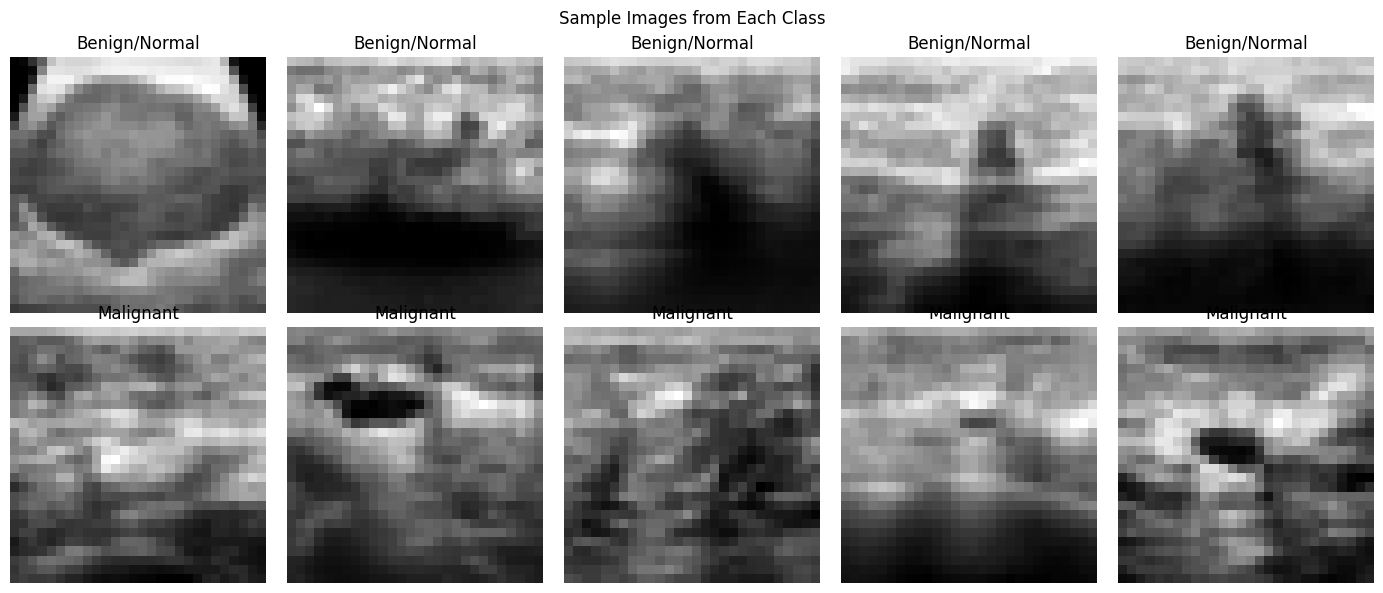

In [3]:
# Display sample images
class_labels = ['Benign/Normal', 'Malignant']
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for row, label in enumerate([0, 1]):
    indices = np.where(y_train == label)[0][:5]
    for col, idx in enumerate(indices):
        axes[row, col].imshow(X_train[idx].squeeze(), cmap='gray')
        axes[row, col].set_title(class_labels[label])
        axes[row, col].axis('off')
plt.suptitle('Sample Images from Each Class')
plt.tight_layout()
plt.show()

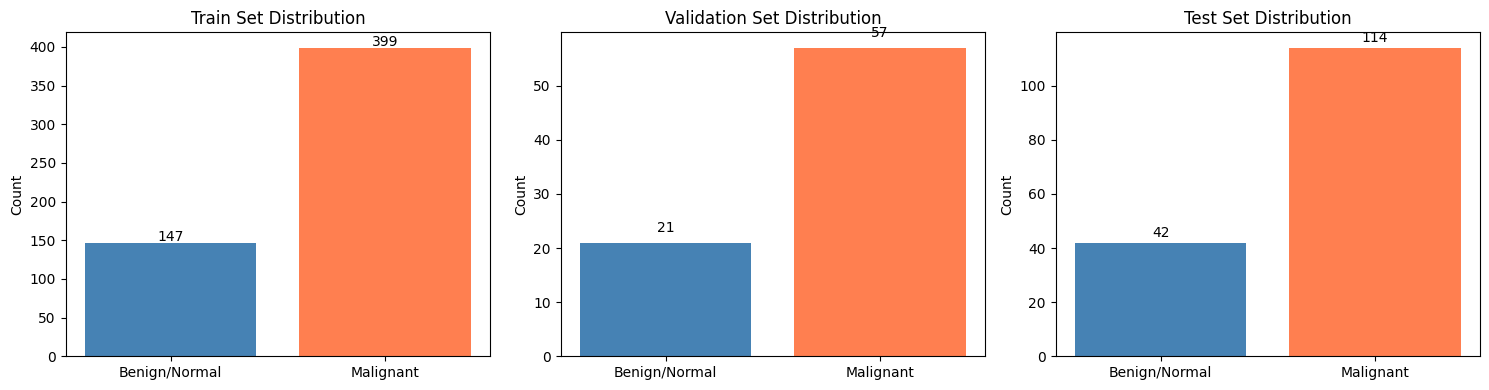

In [4]:
# Class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(axes, [y_train, y_val, y_test], ['Train', 'Validation', 'Test']):
    counts = np.bincount(data)
    ax.bar(class_labels, counts, color=['steelblue', 'coral'])
    ax.set_title(f'{title} Set Distribution')
    ax.set_ylabel('Count')
    for i, c in enumerate(counts):
        ax.text(i, c + 2, str(c), ha='center')
plt.tight_layout()
plt.show()

## Data Augmentation

In [5]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)
datagen.fit(X_train)

## Build CNN Model

In [6]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\himma\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             

 Total params: 296,545 (1.13 MB)

 Trainable params: 295,649 (1.13 MB)

 Non-trainable params: 896 (3.50 KB)

## Train the Model

In [7]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20


 1/18 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.5312 - loss: 1.2108

 4/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5579 - loss: 1.0661

 7/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5550 - loss: 1.0737

10/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5511 - loss: 1.0682

...

 7/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6806 - loss: 0.6548

11/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6842 - loss: 0.6601

14/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6854 - loss: 0.6601

17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6877 - loss: 0.6572

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7106 - loss: 0.6197 - val_accuracy: 0.7308 - val_loss: 1.0158 - learning_rate: 5.0000e-04


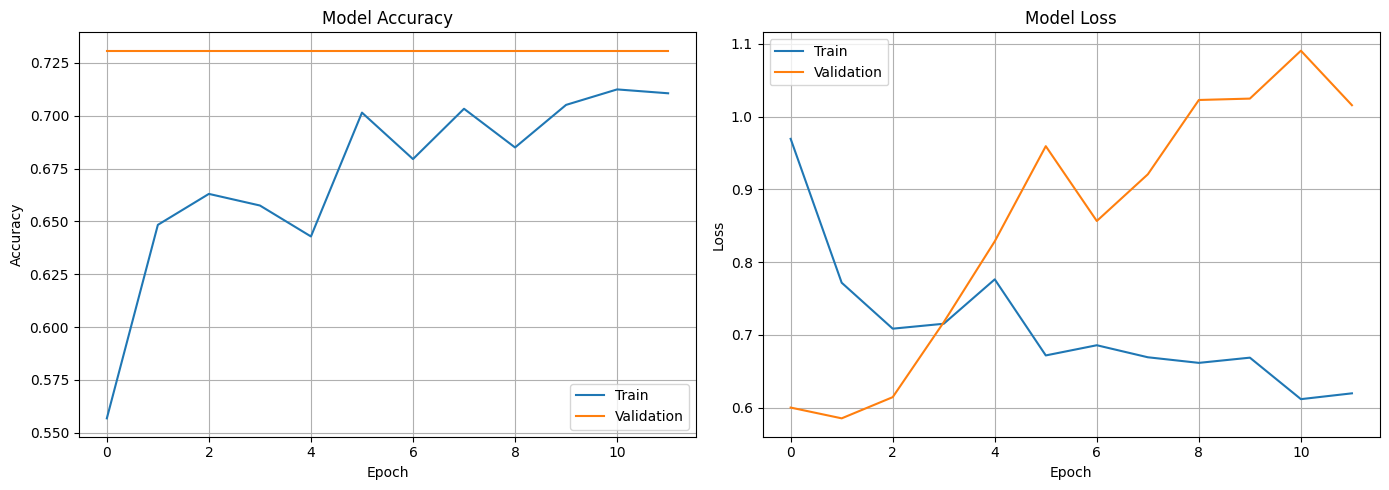

In [8]:
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Evaluation Results

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Loss: {test_loss:.4f}')

Test Accuracy: 0.7308
Test Loss: 0.5856


In [10]:
# Predictions
y_pred_prob = model.predict(X_test).flatten()
y_pred_classes = (y_pred_prob >= 0.5).astype(int)

# Classification Report
print('Classification Report:\n')
print(classification_report(y_test, y_pred_classes, target_names=class_labels))

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


Classification Report:

               precision    recall  f1-score   support

Benign/Normal       0.00      0.00      0.00        42
    Malignant       0.73      1.00      0.84       114

     accuracy                           0.73       156
    macro avg       0.37      0.50      0.42       156
 weighted avg       0.53      0.73      0.62       156



C:\Users\himma\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\himma\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\himma\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

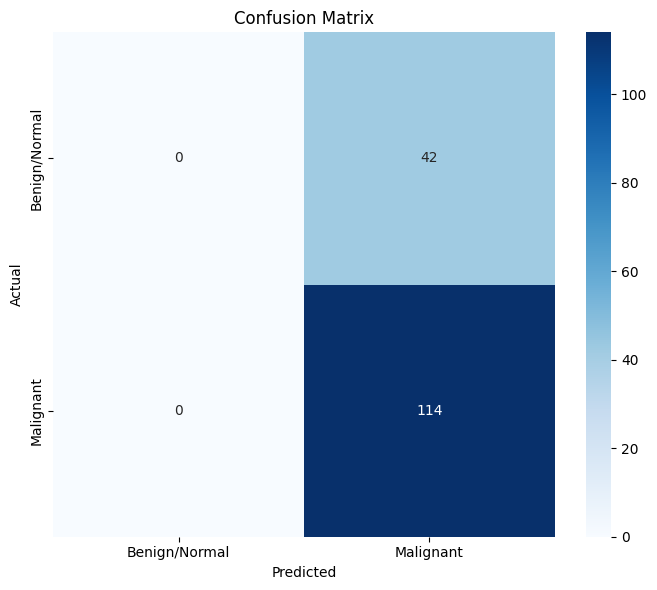

Sensitivity (Recall): 1.0000
Specificity: 0.0000
False Positive Rate: 1.0000
False Negative Rate: 0.0000


In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Derived metrics
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print(f'Sensitivity (Recall): {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')
print(f'False Positive Rate: {fp / (fp + tn):.4f}')
print(f'False Negative Rate: {fn / (fn + tp):.4f}')

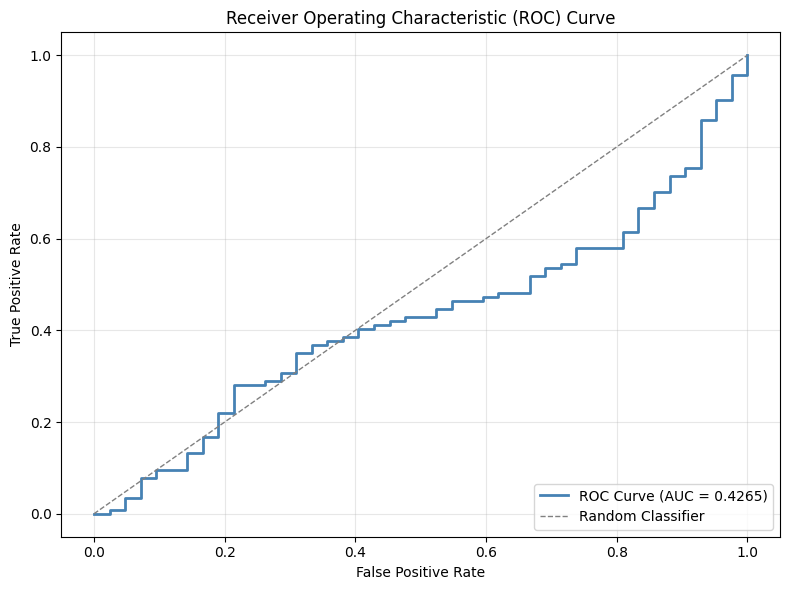

AUC Score: 0.4265


In [12]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC Score: {roc_auc:.4f}')

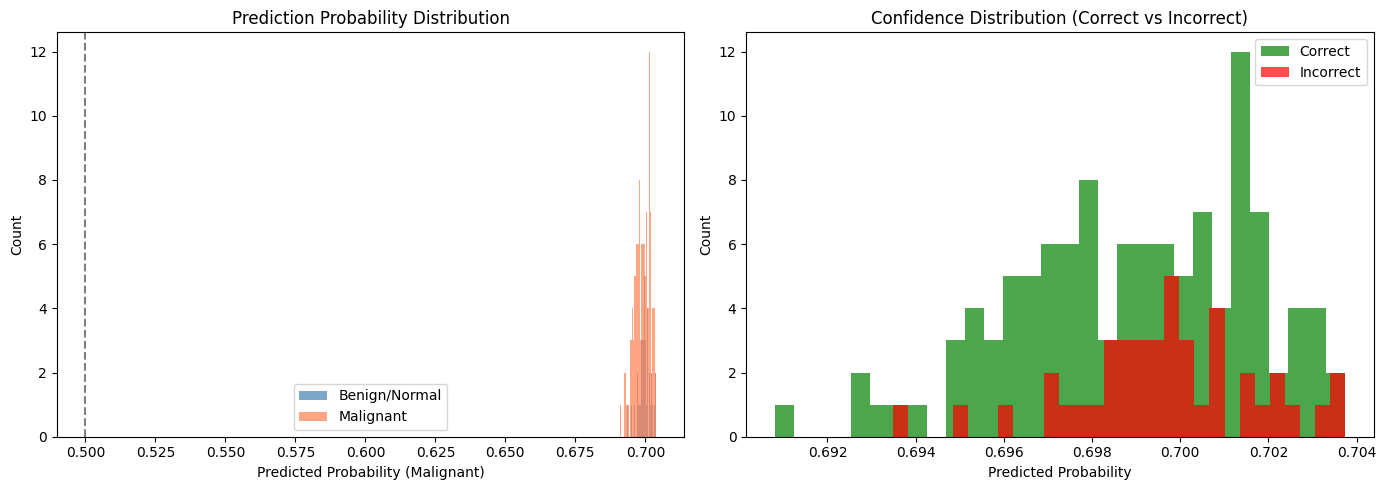

In [13]:
# Prediction confidence distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(y_pred_prob[y_test == 0], bins=30, alpha=0.7, color='steelblue', label='Benign/Normal')
ax1.hist(y_pred_prob[y_test == 1], bins=30, alpha=0.7, color='coral', label='Malignant')
ax1.set_title('Prediction Probability Distribution')
ax1.set_xlabel('Predicted Probability (Malignant)')
ax1.set_ylabel('Count')
ax1.legend()
ax1.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)

# Correct vs incorrect confidence
correct = y_pred_prob[y_pred_classes == y_test]
incorrect = y_pred_prob[y_pred_classes != y_test]
ax2.hist(correct, bins=30, alpha=0.7, color='green', label='Correct')
if len(incorrect) > 0:
    ax2.hist(incorrect, bins=30, alpha=0.7, color='red', label='Incorrect')
ax2.set_title('Confidence Distribution (Correct vs Incorrect)')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Count')
ax2.legend()

plt.tight_layout()
plt.show()

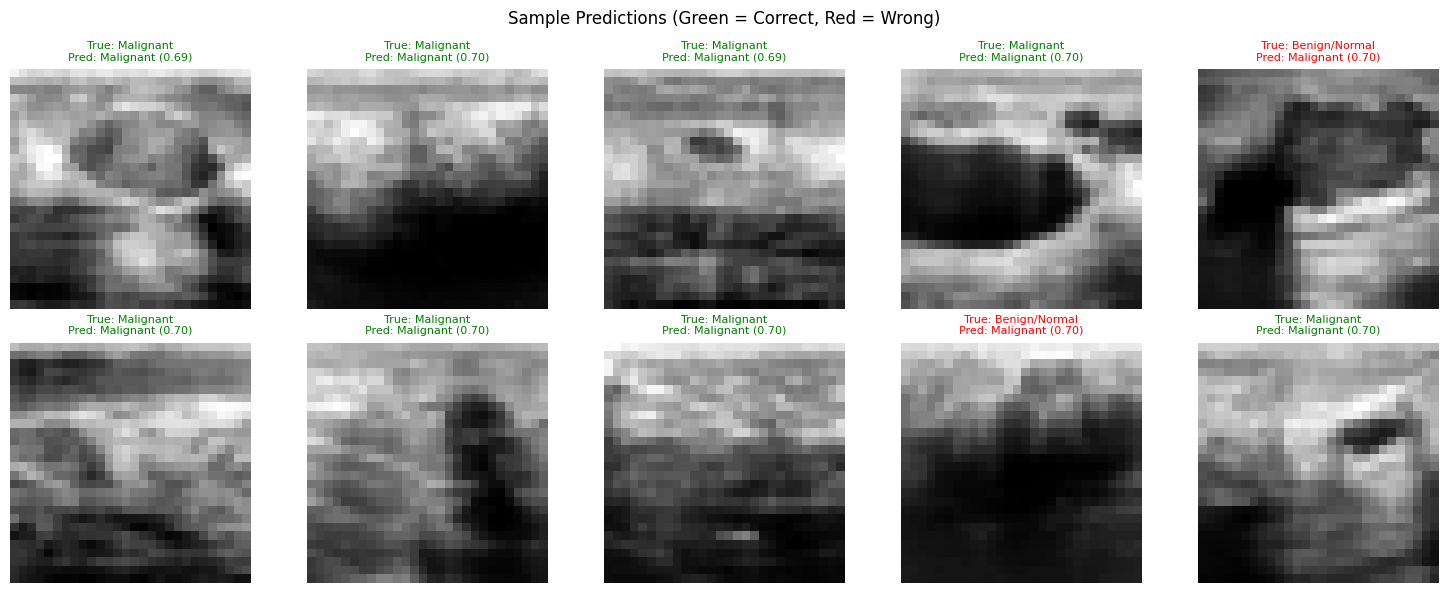

In [14]:
# Sample Predictions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
indices = np.random.choice(len(X_test), 10, replace=False)
for i, ax in enumerate(axes.flat):
    idx = indices[i]
    ax.imshow(X_test[idx].squeeze(), cmap='gray')
    pred = y_pred_classes[idx]
    true = y_test[idx]
    prob = y_pred_prob[idx]
    color = 'green' if pred == true else 'red'
    ax.set_title(f'True: {class_labels[true]}\nPred: {class_labels[pred]} ({prob:.2f})',
                color=color, fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Predictions (Green = Correct, Red = Wrong)')
plt.tight_layout()
plt.show()

## Summary

| Metric | Value |
|---|---|
| Test Accuracy | See above |
| AUC Score | See above |
| Sensitivity | See above |
| Specificity | See above |

The model uses a CNN architecture trained on breast ultrasound images from the BreastMNIST dataset to distinguish between benign/normal and malignant cases. Data augmentation and regularization (Dropout, BatchNorm) were used to improve generalization.